# 07 — Strategy Interpretation

`06_strategy_ablation.ipynb` established that the 8 rhetorical-strategy scores, combined with `word_count`, form the strongest feature combination found anywhere in that notebook (PR-AUC 0.5399, `XGB (over)`), and that their contribution survives length control almost undiminished — unlike everything else examined. This notebook asks the natural follow-up question: *which* strategies actually drive that result?

Four steps: first, how the 8 raw strategy scores are actually distributed (several turn out to be heavily floor-loaded, which matters for how much weight to put on what follows); then two complementary views of what drives the model, each repeated once on the full scored population and once on a length-matched sample (to check whether a strategy's apparent importance is itself a length artifact):
1. **SHAP beeswarm** — how each strategy pushes the model's predictions, feature by feature, on the winning model from `06`.
2. **Mann-Whitney U effect sizes** — a model-free comparison of each strategy's score distribution between convincing and non-convincing comments, FDR-corrected across the 8 tests.

Finally, a pruning check: do the strategies both views agree are weak actually cost anything if dropped from the model?

## Setup

In [1]:
import pandas as pd

comments_df = pd.read_csv('../results/05_cmv_comments_df.csv.zip')
comments_df = comments_df.copy()  # consolidate blocks - avoids a pandas PerformanceWarning on later single-column inserts

STRATEGY_NAMES = ['justification', 'concession', 'evidence', 'refutation',
                   'personal_narrative', 'call_to_action', 'simplification', 'question_asking']

print(f'Loaded {len(comments_df)} rows, {comments_df.shape[1]} columns')
print(f'Positive rate: {comments_df["is_convincing"].mean():.3f}')

Loaded 2753 rows, 246 columns
Positive rate: 0.233


This notebook's baseline convincing rate is 23.3%, noticeably higher than the ~16.1% baseline `03.x` and earlier notebooks use. It's the same 641 convincing comments either way, not a different population: `05_rhetorical_scoring.ipynb` only scored comments that are ≥30 words long or convincing (scoring an 8-strategy rubric on a one-line reply isn't meaningful), which drops 1,218 short, non-convincing comments from the denominator (3,971 → 2,753) while every convincing comment stays in. 641/3,971 = 16.1%; 641/2,753 = 23.3% — same numerator, smaller denominator. Any baseline-rate comparison against `03.x`-era notebooks needs to account for this, not treat the two percentages as directly comparable.

In [2]:
import hashlib

comments_df['thread_id'] = comments_df['original_post'].apply(
    lambda x: hashlib.md5(str(x).encode()).hexdigest()
)

print(f'Unique threads : {comments_df["thread_id"].nunique()}')
print(f'Total comments : {len(comments_df)}')

Unique threads : 400
Total comments : 2753


## Strategy Score Distributions

Before interpreting the model, it's worth seeing how the 8 raw strategy scores are actually distributed. Several of them turn out to be heavily floor-loaded — most comments scoring 1 ("not present") — which matters for how much weight the SHAP and Mann-Whitney results further down should get at their high-score end. Same `plot_category_histogram` convention `03.x` used for other discrete LLM-scored and categorical features, run on the full 2,753-row scored population.

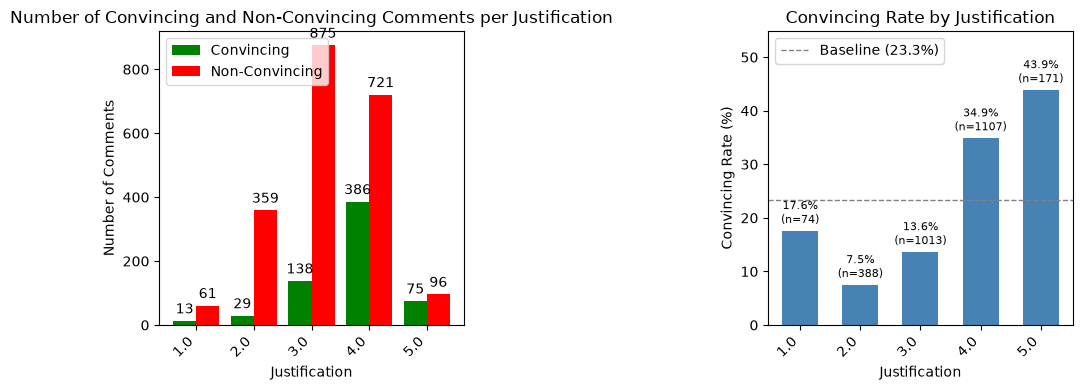

In [3]:
import common_functions

common_functions.plot_category_histogram(comments_df, 'justification', 'Justification', show_counts=True, figsize=(5, 4), panel_gap=1.0, sort_by_value=True)

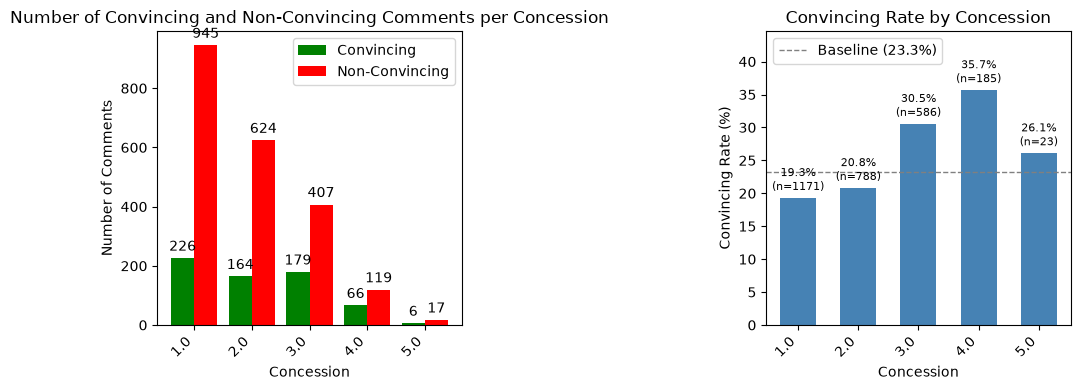

In [4]:
common_functions.plot_category_histogram(comments_df, 'concession', 'Concession', show_counts=True, figsize=(5, 4), panel_gap=1.0, sort_by_value=True)

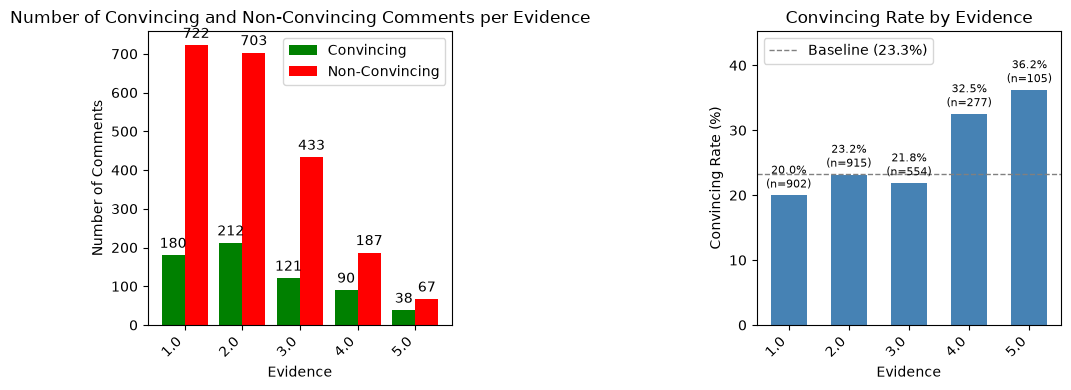

In [5]:
common_functions.plot_category_histogram(comments_df, 'evidence', 'Evidence', show_counts=True, figsize=(5, 4), panel_gap=1.0, sort_by_value=True)

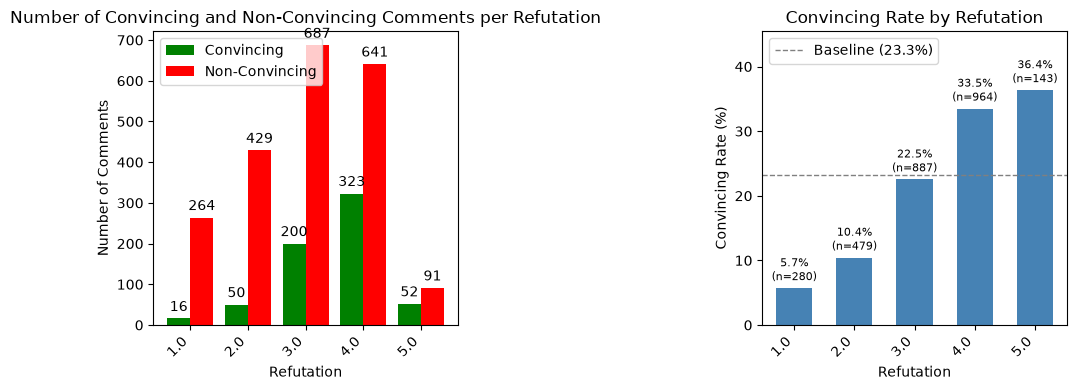

In [6]:
common_functions.plot_category_histogram(comments_df, 'refutation', 'Refutation', show_counts=True, figsize=(5, 4), panel_gap=1.0, sort_by_value=True)

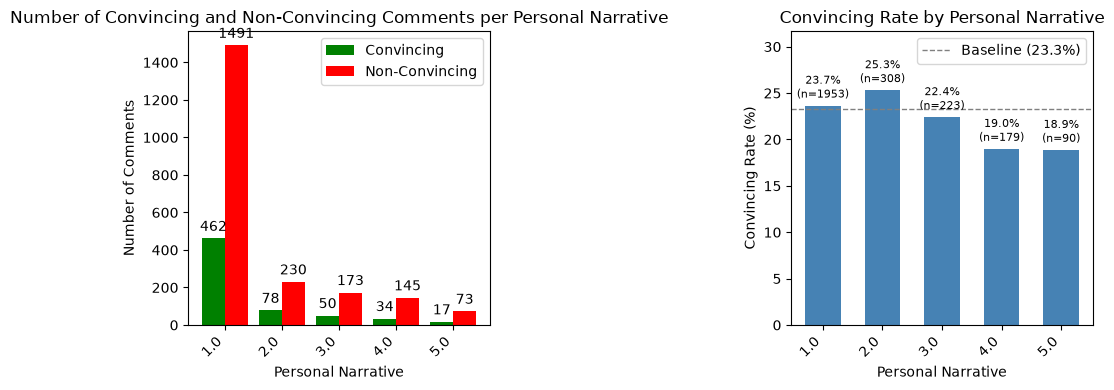

In [7]:
common_functions.plot_category_histogram(comments_df, 'personal_narrative', 'Personal Narrative', show_counts=True, figsize=(5, 4), panel_gap=1.0, sort_by_value=True)

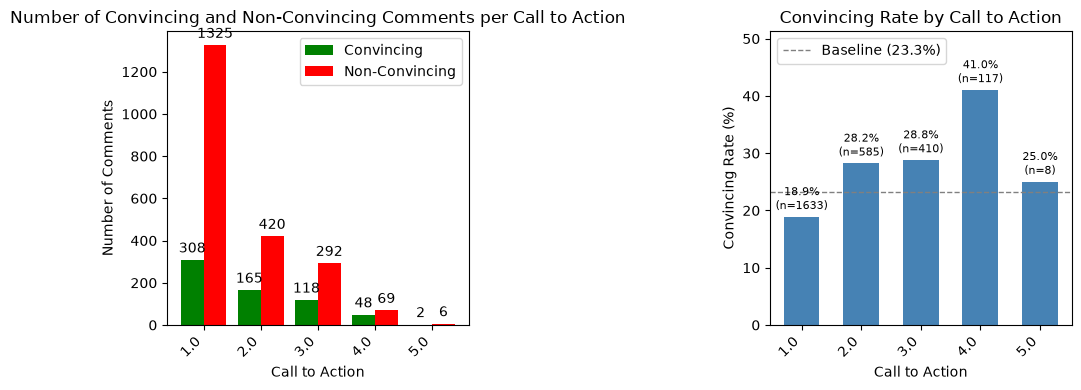

In [8]:
common_functions.plot_category_histogram(comments_df, 'call_to_action', 'Call to Action', show_counts=True, figsize=(5, 4), panel_gap=1.0, sort_by_value=True)

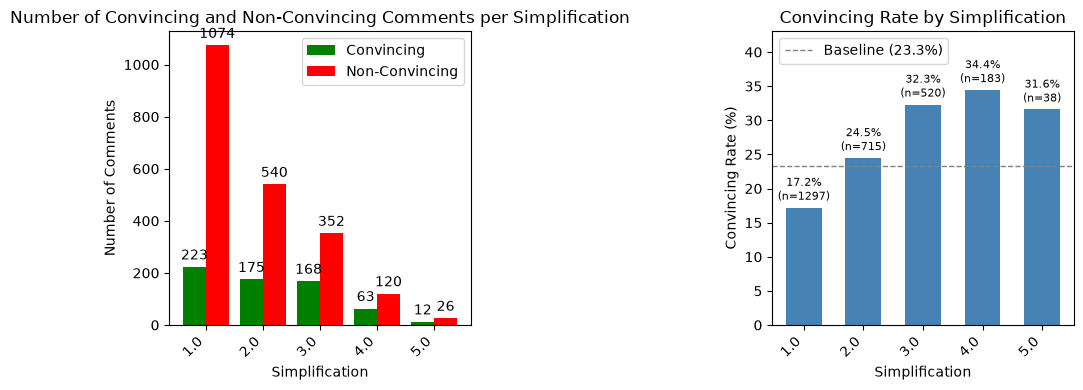

In [9]:
common_functions.plot_category_histogram(comments_df, 'simplification', 'Simplification', show_counts=True, figsize=(5, 4), panel_gap=1.0, sort_by_value=True)

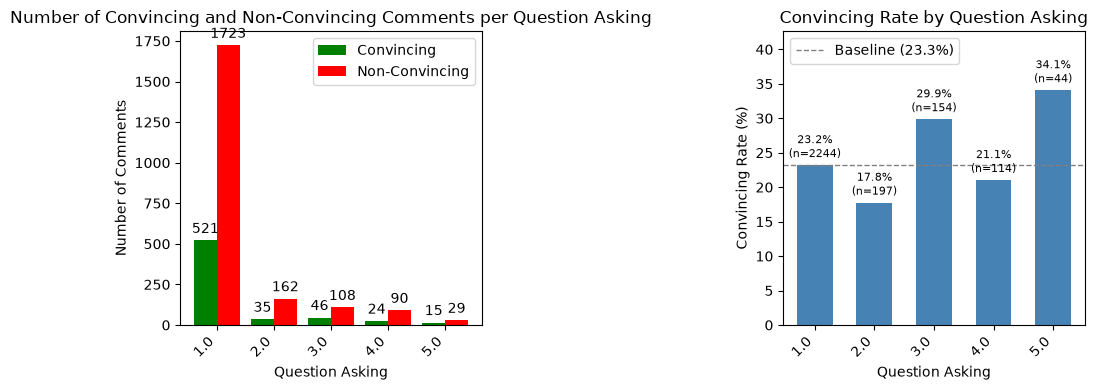

In [10]:
common_functions.plot_category_histogram(comments_df, 'question_asking', 'Question Asking', show_counts=True, figsize=(5, 4), panel_gap=1.0, sort_by_value=True)

**Most strategies are heavily floor-loaded — only `justification` and `refutation` are actually used by most comments.** `question_asking` (81.5% of comments score 1) and `personal_narrative` (70.9%) are almost always absent; `call_to_action` (59.3%), `simplification` (47.1%), and `concession` (42.5%) are absent in close to or over half the dataset. `evidence` (32.8% at floor) is better populated, and `justification` (2.7%) and `refutation` (10.2%) are the only two strategies most comments actually score above "not present" on.

The convincing-rate panels add a second axis: `refutation`, `simplification`, `evidence`, and `justification` (past its noisy score 1/2 buckets) all show a rising convincing rate with score — the kind of relationship a classifier can use. `personal_narrative` trends slightly *down* with score instead, and `question_asking`'s rate sits close to the ~23% baseline at every bucket with no consistent direction — both stand out as candidates for pruning later. The thin top buckets of `call_to_action` (n=8 at score 5) and `concession` (n=23 at score 5) are worth flagging too — any reading of those specific bars is closer to anecdotal than statistical.

### Are the Floor-Loaded Strategies Substituted by Other Strategies?

A comment that's absent on one of the floor-loaded strategies above could still be making its case some other way — leaning on a different strategy from the other 7 instead. If so, that absence wouldn't mean the comment lacks persuasive technique, just that this particular dimension doesn't apply to it. Checking that directly, before drawing conclusions from the distributions above.

In [11]:
floor_heavy = ['question_asking', 'personal_narrative', 'call_to_action', 'simplification', 'concession']
overall_mean = comments_df[STRATEGY_NAMES].mean()

substitution_table = pd.DataFrame({
    s: comments_df.loc[comments_df[s] == 1, STRATEGY_NAMES].mean() - overall_mean
    for s in floor_heavy
}).T
for s in floor_heavy:
    substitution_table.loc[s, s] = float('nan')  # a strategy's own column here is trivially negative - these rows are selected on it being absent

substitution_table.round(3)

,justification,concession,evidence,refutation,personal_narrative,call_to_action,simplification,question_asking
question_asking,-0.025,0.013,-0.002,-0.080,0.023,0.001,-0.034,NaN
personal_narrative,-0.009,-0.104,-0.023,0.082,NaN,-0.013,0.052,0.021
call_to_action,-0.206,-0.182,-0.021,-0.089,-0.025,NaN,-0.143,0.005
simplification,-0.399,-0.153,-0.060,-0.316,0.083,-0.158,NaN,-0.042
concession,-0.343,NaN,-0.146,-0.214,-0.104,-0.190,-0.167,0.031


In [12]:
all_absent = (comments_df[STRATEGY_NAMES] == 1).all(axis=1)
print(f'Comments scoring 1 (absent) on all 8 strategies: {all_absent.sum()} ({all_absent.mean()*100:.1f}%)')
print(f'  convincing rate among them: {comments_df.loc[all_absent, "is_convincing"].mean()*100:.1f}%  '
      f'(overall: {comments_df["is_convincing"].mean()*100:.1f}%)')
print(f'  mean word_count: {comments_df.loc[all_absent, "word_count"].mean():.1f}  '
      f'(overall: {comments_df["word_count"].mean():.1f})')

Comments scoring 1 (absent) on all 8 strategies: 29 (1.1%)
  convincing rate among them: 13.8%  (overall: 23.3%)
  mean word_count: 85.1  (overall: 138.2)


**No real substitution — absence mostly means absence.** Each cell above is the mean score on another strategy, among comments that score 1 (absent) on the row's strategy, minus the overall population mean — so a positive value would mean "comments lacking this strategy lean on that one instead." For `question_asking` and `personal_narrative`, every value is within ±0.08 of zero: comments without them look like an average comment in every other respect, not comments compensating with a different tactic. `call_to_action`, `simplification`, and `concession` show the opposite of substitution — their absence correlates with *lower* `justification` and `refutation` too (e.g. `simplification`-absent comments average 2.93 on `justification` vs. 3.33 overall, and 2.76 on `refutation` vs. 3.08), suggesting these are generally thinner arguments overall, not arguments leaning on a different strategy instead.

Only 29 comments (1.1%) score absent on all 8 strategies at once — the one group where the taxonomy genuinely finds nothing. They're shorter than average (85 vs. 138 words) and convince at less than half the baseline rate (13.8% vs. 23.3%), consistent with being low-effort comments rather than comments built on some rhetorical approach outside the 8-strategy taxonomy. There's no strong evidence here that the floor-loaded strategies are hiding an unrepresented 9th strategy — they look like genuinely optional tactics most comments simply don't use.

The model interpreted throughout this notebook is `06`'s winning combination: `XGB (over)` (XGBoost with SMOTE oversampling) fit on the 8 strategy scores plus `word_count` — the strongest feature set found in that notebook, and the natural target for asking which of its 9 inputs matter most. Refit here, self-contained, rather than depending on `06` having been run first.

In [13]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import RobustScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb

BEST_FEATURE_COLS = STRATEGY_NAMES + ['word_count']
X = comments_df[BEST_FEATURE_COLS]
y = comments_df['is_convincing']
groups = comments_df['thread_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

train_threads = set(groups.iloc[train_idx])
test_threads  = set(groups.iloc[test_idx])
assert len(train_threads & test_threads) == 0, 'LEAKAGE: shared threads between train and test!'
print(f'Train: {len(train_idx)} comments from {len(train_threads)} threads')
print(f'Test : {len(test_idx)} comments from {len(test_threads)} threads')

Train: 2161 comments from 320 threads
Test : 592 comments from 80 threads


In [14]:
def make_selected_pipe():
    return Pipeline([
        ('scaler', RobustScaler()),
        ('sampler', SMOTE(random_state=42)),
        ('clf', xgb.XGBClassifier(random_state=42, eval_metric='logloss')),
    ])

from sklearn.metrics import average_precision_score, roc_auc_score

selected_pipe = make_selected_pipe()
selected_pipe.fit(X_train, y_train)
proba_test = selected_pipe.predict_proba(X_test)[:, 1]

print(f'Test PR-AUC : {average_precision_score(y_test, proba_test):.4f}')
print(f'Test ROC-AUC: {roc_auc_score(y_test, proba_test):.4f}')
print(f'No-skill PR-AUC baseline (test-fold positive rate): {y_test.mean():.4f}')

Test PR-AUC : 0.5399
Test ROC-AUC: 0.7789
No-skill PR-AUC baseline (test-fold positive rate): 0.2382


## SHAP Beeswarm

SHAP (SHapley Additive exPlanations) attributes each prediction to its input features, based on the fitted classifier itself rather than a separate statistical test — this shows what the model actually learned to rely on, which need not match a simple univariate comparison (the next section). `TreeExplainer` is applied directly to the fitted `XGBClassifier` step, on the test set transformed through the pipeline's `RobustScaler` (the same input the classifier itself sees) — `SMOTE` is fit-only and does not apply at prediction time, so no adjustment is needed for it.

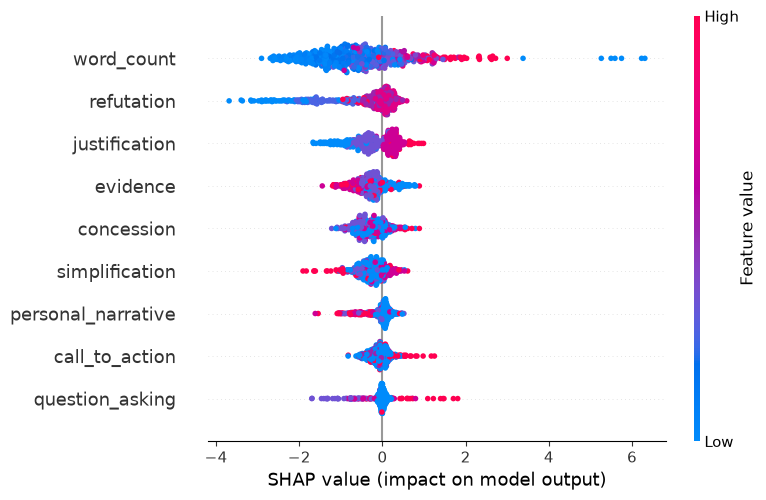

In [15]:
import shap

X_test_scaled = pd.DataFrame(
    selected_pipe.named_steps['scaler'].transform(X_test),
    columns=X_test.columns, index=X_test.index,
)

explainer = shap.TreeExplainer(selected_pipe.named_steps['clf'])
shap_values = explainer(X_test_scaled)

import matplotlib.pyplot as plt
shap.plots.beeswarm(shap_values, show=False)
plt.tight_layout()
plt.show()

In [16]:
mean_abs_shap = pd.Series(np.abs(shap_values.values).mean(axis=0), index=X_test.columns)
mean_abs_shap = mean_abs_shap.sort_values(ascending=False)
mean_abs_shap.to_frame('mean |SHAP value|')

,mean |SHAP value|
word_count,1.024517
refutation,0.603366
justification,0.415608
evidence,0.359189
concession,0.343910
simplification,0.319318
personal_narrative,0.185313
call_to_action,0.183688
question_asking,0.151755


In [17]:
shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns, index=X_test.index)

shap_by_score_mean = pd.DataFrame({
    strategy: shap_df[strategy].groupby(X_test[strategy]).mean()
    for strategy in STRATEGY_NAMES
}).T
shap_by_score_mean.columns = [f'score {int(c)}' for c in shap_by_score_mean.columns]
shap_by_score_mean.round(4)

,score 1,score 2,score 3,score 4,score 5
justification,-1.1308,-0.8580,-0.3578,0.2277,0.4328
concession,-0.2179,-0.4808,-0.1688,0.0732,-0.2703
evidence,0.0213,-0.2604,-0.5928,-0.3087,-0.4174
refutation,-2.3547,-1.1965,-0.0664,0.1015,-0.4634
personal_narrative,0.0502,-0.0991,-0.4655,-0.4643,-0.5838
call_to_action,-0.0900,-0.0995,0.0331,0.0173,1.2493
simplification,-0.2513,-0.3314,0.0039,-0.4531,-1.3713
question_asking,0.0011,-0.8572,-0.2027,-0.0538,1.0185


In [18]:
shap_by_score_n = pd.DataFrame({
    strategy: shap_df[strategy].groupby(X_test[strategy]).count()
    for strategy in STRATEGY_NAMES
}).T
shap_by_score_n.columns = [f'score {int(c)}' for c in shap_by_score_n.columns]
shap_by_score_n

,score 1,score 2,score 3,score 4,score 5
justification,19,88,220,227,38
concession,237,187,132,31,5
evidence,173,206,138,59,16
refutation,60,111,182,205,34
personal_narrative,412,66,49,48,17
call_to_action,375,129,76,11,1
simplification,287,152,103,39,11
question_asking,477,41,37,23,14


In [19]:
print("Correlation of `evidence` with the model's other 8 inputs (full scored population):")
print(comments_df[STRATEGY_NAMES + ['word_count']].corr()['evidence'].drop('evidence').sort_values(ascending=False).round(4))

print('\nMean word_count by evidence score (full scored population):')
comments_df.groupby('evidence')['word_count'].agg(['mean', 'median', 'count']).round(1)

Correlation of `evidence` with the model's other 8 inputs (full scored population):
justification         0.3961
refutation            0.3514
word_count            0.3434
concession            0.1074
simplification        0.0305
call_to_action        0.0114
personal_narrative    0.0095
question_asking      -0.0275
Name: evidence, dtype: float64

Mean word_count by evidence score (full scored population):


,mean,median,count
evidence,,,
1.0,87.6,65.0,902
2.0,128.3,93.0,915
3.0,166.3,112.0,554
4.0,215.0,139.0,277
5.0,309.9,216.0,105


**`word_count` dwarfs every strategy in raw SHAP impact — unsurprising, given it's the strongest single predictor in the whole project — but among the 8 strategies, `refutation` stands out clearly** (mean |SHAP| 0.603), roughly 1.5x the next-highest (`justification`, 0.416). `evidence`, `concession`, and `simplification` form a second tier; `question_asking` is the least influential strategy in the model.

**Breaking SHAP down by each strategy's raw 1-5 score (above) shows three distinct shapes, not one:**

- **`refutation` has a floor effect:** scoring 1-2 costs -2.35/-1.20, while scoring 3-4 barely helps (-0.07/+0.10) — well-populated at every level (n=60-205), so this isn't thin-data noise, just a strongly asymmetric relationship.
- **`question_asking` sits close to zero at every score** (-0.001 to -0.86, no consistent direction, and 477 of 592 test comments never use it at all) — the clearest case of a strategy the model has learned to essentially ignore, consistent with the floor effect seen in its distribution above.
- **`evidence` is the odd one out:** its SHAP value dips hardest at score 3 (-0.59), not at either extreme, which doesn't fit a simple "more is better" or floor-effect story. It correlates moderately with `justification` (r=0.40), `refutation` (r=0.35), and `word_count` (r=0.34) — and mean `word_count` rises steeply with its score, from 88 words at score 1 to 310 at score 5. Once `word_count`, `justification`, and `refutation` have already claimed credit for the same "well-developed argument" signal, the model appears to discount `evidence` itself rather than reward it further — a redundancy effect between correlated features, not `evidence` actively hurting predictions on its own.

## Mann-Whitney U Effect Sizes

A complementary, model-free view: for each of the 8 strategies independently, does its score distribution differ between convincing and non-convincing comments? Mann-Whitney U (rather than a t-test) since the scores are ordinal 1-5 ratings, not continuous/normal. Effect size is the rank-biserial correlation (`2U/(n1*n2) - 1`, ranging -1 to 1), and p-values are FDR-corrected (Benjamini-Hochberg) across the 8 simultaneous tests to control the false-discovery rate.

In [20]:
from scipy.stats import mannwhitneyu

def benjamini_hochberg(p_values):
    """Benjamini-Hochberg FDR-adjusted p-values - avoids adding statsmodels as a dependency
    for a single well-known procedure."""
    p = np.asarray(p_values)
    m = len(p)
    order = np.argsort(p)
    ranked = p[order] * m / np.arange(1, m + 1)
    adjusted = np.minimum.accumulate(ranked[::-1])[::-1]
    result = np.empty(m)
    result[order] = np.clip(adjusted, 0, 1)
    return result

def strategy_effect_sizes(df):
    """Mann-Whitney U + rank-biserial effect size per strategy, FDR-corrected across the 8 tests."""
    convincing = df[df['is_convincing'] == 1]
    non_convincing = df[df['is_convincing'] == 0]

    rows = {}
    for strategy in STRATEGY_NAMES:
        conv_scores = convincing[strategy]
        non_conv_scores = non_convincing[strategy]
        u_stat, p_value = mannwhitneyu(conv_scores, non_conv_scores, alternative='two-sided')
        n1, n2 = len(conv_scores), len(non_conv_scores)
        rank_biserial = 2 * u_stat / (n1 * n2) - 1
        rows[strategy] = {
            'mean (convincing)': conv_scores.mean(),
            'mean (non-convincing)': non_conv_scores.mean(),
            'rank-biserial r': rank_biserial,
            'p-value': p_value,
        }

    result = pd.DataFrame(rows).T
    result['p-value (FDR)'] = benjamini_hochberg(result['p-value'].values)
    result['significant (FDR < 0.05)'] = result['p-value (FDR)'] < 0.05
    return result.sort_values('rank-biserial r', ascending=False)

effect_sizes_full = strategy_effect_sizes(comments_df)
effect_sizes_full.round(4)

,mean (convincing),mean (non-convincing),rank-biserial r,p-value,p-value (FDR),significant (FDR < 0.05)
justification,3.7504,3.2045,0.3584,0.0000,0.0000,True
refutation,3.5382,2.9366,0.3149,0.0000,0.0000,True
simplification,2.1669,1.8087,0.1944,0.0000,0.0000,True
call_to_action,1.8627,1.5848,0.1584,0.0000,0.0000,True
concession,2.1607,1.8821,0.1481,0.0000,0.0000,True
evidence,2.3666,2.1354,0.1018,0.0000,0.0001,True
question_asking,1.4041,1.3617,0.0069,0.6964,0.6964,False
personal_narrative,1.5429,1.6170,-0.0217,0.2979,0.3405,False


**`justification` and `refutation` separate convincing from non-convincing comments most clearly, and this partially diverges from the SHAP ranking above.** Both have the largest rank-biserial effect sizes (0.358 and 0.315) and are the two strategies flagged in `05`'s validation (§2.3) as hardest for the LLM to calibrate against human judgment — the strongest univariate signal comes from the two noisiest-scored strategies, not the cleanest ones. `simplification`, `call_to_action`, `concession`, and `evidence` are all statistically significant after FDR correction but with smaller effect sizes; `question_asking` and `personal_narrative` are not distinguishable from chance at all (FDR-adjusted p = 0.696 and 0.340). `refutation` agrees with SHAP's top strategy, but `justification` — Mann-Whitney's top strategy — ranked third in mean |SHAP|, ahead of it only by `word_count` and `refutation` themselves: the two views mostly agree on what matters, but not on the exact ordering, since SHAP reflects the model's learned, correlation-aware use of a feature while Mann-Whitney measures each strategy's distributional separation in isolation.

## Repeating on the Length-Matched Sample

Both views above are run on the full scored population, where `word_count` and `is_convincing` are still correlated (`06` measured this at r=0.29 within the scored population). A strategy could look important above simply because longer comments use it more, not because the strategy itself is persuasive. This section rebuilds the strict 1:1 length-matched sample from `06`'s Length-Controlled Benchmark — decile-matching non-convincing comments' `word_count` to convincing comments' distribution, within the scored population (the same adaptation `06` used, since strategy scores only exist for `word_count >= 30`) — and repeats both the SHAP and Mann-Whitney analyses on it.

In [21]:
n_bins = 10
conv_df    = comments_df[comments_df['is_convincing'] == 1].copy()
nonconv_df = comments_df[comments_df['is_convincing'] == 0].copy()

bin_edges = pd.qcut(conv_df['word_count'], n_bins, duplicates='drop', retbins=True)[1]
conv_df['length_bin']    = pd.cut(conv_df['word_count'], bins=bin_edges, include_lowest=True)
nonconv_df['length_bin'] = pd.cut(nonconv_df['word_count'], bins=bin_edges, include_lowest=True)

matched_parts = []
for bin_label, group in conv_df.groupby('length_bin', observed=True):
    pool = nonconv_df[nonconv_df['length_bin'] == bin_label]
    take_n = min(len(group), len(pool))
    if take_n > 0:
        matched_parts.append(pool.sample(n=take_n, random_state=42))

matched_nonconv_df = pd.concat(matched_parts) if matched_parts else nonconv_df.iloc[:0]
comments_df_matched = pd.concat([conv_df, matched_nonconv_df]).drop(columns='length_bin').sort_index()

from scipy.stats import pointbiserialr
r_matched, p_matched = pointbiserialr(comments_df_matched['is_convincing'], comments_df_matched['word_count'])
print(f'Length-matched sample: {len(comments_df_matched)} comments '
      f'({int(comments_df_matched["is_convincing"].sum())} convincing, '
      f'positive rate {comments_df_matched["is_convincing"].mean():.3f})')
print(f'word_count correlation after matching: r={r_matched:.4f}, p={p_matched:.2e}')

Length-matched sample: 1235 comments (641 convincing, positive rate 0.519)
word_count correlation after matching: r=0.0608, p=3.27e-02


In [22]:
X_matched = comments_df_matched[BEST_FEATURE_COLS]
y_matched = comments_df_matched['is_convincing']
groups_matched = comments_df_matched['thread_id']

gss_matched = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_m, test_idx_m = next(gss_matched.split(X_matched, y_matched, groups=groups_matched))
X_train_m, X_test_m = X_matched.iloc[train_idx_m], X_matched.iloc[test_idx_m]
y_train_m, y_test_m = y_matched.iloc[train_idx_m], y_matched.iloc[test_idx_m]

assert len(set(groups_matched.iloc[train_idx_m]) & set(groups_matched.iloc[test_idx_m])) == 0

selected_pipe_m = make_selected_pipe()
selected_pipe_m.fit(X_train_m, y_train_m)
proba_test_m = selected_pipe_m.predict_proba(X_test_m)[:, 1]

print(f'Train: {len(train_idx_m)}  Test: {len(test_idx_m)}')
print(f'Test PR-AUC : {average_precision_score(y_test_m, proba_test_m):.4f}')
print(f'No-skill PR-AUC baseline (test-fold positive rate): {y_test_m.mean():.4f}')

Train: 970  Test: 265
Test PR-AUC : 0.6615
No-skill PR-AUC baseline (test-fold positive rate): 0.5132


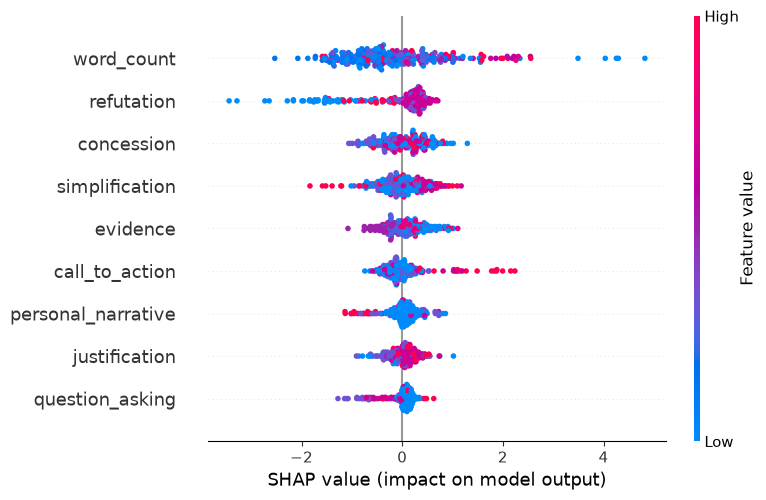

In [23]:
X_test_m_scaled = pd.DataFrame(
    selected_pipe_m.named_steps['scaler'].transform(X_test_m),
    columns=X_test_m.columns, index=X_test_m.index,
)

explainer_m = shap.TreeExplainer(selected_pipe_m.named_steps['clf'])
shap_values_m = explainer_m(X_test_m_scaled)

shap.plots.beeswarm(shap_values_m, show=False)
plt.tight_layout()
plt.show()

In [24]:
mean_abs_shap_m = pd.Series(np.abs(shap_values_m.values).mean(axis=0), index=X_test_m.columns)
mean_abs_shap_m = mean_abs_shap_m.sort_values(ascending=False)

shap_comparison = pd.DataFrame({
    'mean |SHAP| (full population)': mean_abs_shap,
    'mean |SHAP| (length-matched)': mean_abs_shap_m,
}).sort_values('mean |SHAP| (length-matched)', ascending=False)
shap_comparison.round(4)

,mean |SHAP| (full population),mean |SHAP| (length-matched)
word_count,1.0245,0.8402
refutation,0.6034,0.5193
concession,0.3439,0.3445
simplification,0.3193,0.3383
evidence,0.3592,0.3090
call_to_action,0.1837,0.2707
personal_narrative,0.1853,0.2168
justification,0.4156,0.1956
question_asking,0.1518,0.1806


In [25]:
shap_df_m = pd.DataFrame(shap_values_m.values, columns=X_test_m.columns, index=X_test_m.index)

evidence_wc_corr_matched = comments_df_matched[['evidence', 'word_count']].corr().iloc[0, 1]
evidence_wc_corr_full    = comments_df[['evidence', 'word_count']].corr().iloc[0, 1]
print(f"`evidence`/`word_count` correlation - length-matched: {evidence_wc_corr_matched:.4f}  "
      f"(full population: {evidence_wc_corr_full:.4f})")
print()
print('Mean SHAP(evidence) by raw score - length-matched sample:')
shap_df_m['evidence'].groupby(X_test_m['evidence']).agg(['mean', 'count']).round(4)

`evidence`/`word_count` correlation - length-matched: 0.3797  (full population: 0.3434)

Mean SHAP(evidence) by raw score - length-matched sample:


,mean,count
evidence,,
1.0,0.3748,70
2.0,0.0252,81
3.0,-0.3707,59
4.0,0.1236,37
5.0,0.2709,18


**`refutation` holds its rank under length control; `justification` does not.** `word_count`'s own SHAP impact drops from 1.0245 to 0.8402 once length is matched, as expected — but `refutation` stays clearly the most influential strategy in both views (0.6034 to 0.5193, a modest decline). `justification`, by contrast, collapses from the model's third most influential feature overall (0.4156) to one of its least influential strategies (0.1956, now behind `concession`, `simplification`, and `evidence`) — most of what the model was using `justification` for on the full population looks length-related, not something that survives once comments of comparable length are compared directly.

`evidence`'s redundancy pattern survives length control too, and in largely the same shape: scoring 3 is still the single most negative point in the matched sample (-0.37, vs. -0.59 on the full population), while scores 1, 2, 4, and 5 all sit at or above zero — smaller in magnitude, but the same dip-in-the-middle shape. The correlation with `word_count` barely drops under matching either (0.38 vs. 0.34 on the full population) — length-matching selects non-convincing comments to mirror convincing comments' length distribution, but it doesn't decorrelate `evidence` from `word_count` within that sample. So `evidence`'s redundancy looks at least as tied to the other strategies (`justification`, `refutation`) as to `word_count` itself.

In [26]:
effect_sizes_matched = strategy_effect_sizes(comments_df_matched)

effect_size_comparison = pd.DataFrame({
    'rank-biserial r (full population)': effect_sizes_full['rank-biserial r'],
    'significant, full (FDR < 0.05)': effect_sizes_full['significant (FDR < 0.05)'],
    'rank-biserial r (length-matched)': effect_sizes_matched['rank-biserial r'],
    'significant, matched (FDR < 0.05)': effect_sizes_matched['significant (FDR < 0.05)'],
}).sort_values('rank-biserial r (length-matched)', ascending=False)
effect_size_comparison.round(4)

,rank-biserial r (full population),"significant, full (FDR < 0.05)",rank-biserial r (length-matched),"significant, matched (FDR < 0.05)"
refutation,0.3149,True,0.1540,True
justification,0.3584,True,0.1309,True
simplification,0.1944,True,0.0789,True
call_to_action,0.1584,True,0.0592,False
concession,0.1481,True,0.0206,False
evidence,0.1018,True,-0.0322,False
question_asking,0.0069,False,-0.0345,False
personal_narrative,-0.0217,False,-0.0859,True


**Only three strategies remain significant after length matching, and the ranking shifts.** `refutation` (0.315 to 0.154, 49% retained) and `justification` (0.358 to 0.131, 37% retained) both stay statistically significant, though each loses well over half its effect size. `simplification` also survives (0.194 to 0.079). `call_to_action`, `concession`, and `evidence` all lose significance entirely once length is controlled — their apparent effect on the full population was largely a length artifact. `personal_narrative` is the one strategy that *gains* significance under matching, flipping to a small but reliable **negative** association (-0.086) — comments leaning on personal narrative become, if anything, less likely to convince once length is no longer confounding the comparison.

This partly disagrees with the SHAP comparison above: Mann-Whitney still finds `justification` significant post-matching (unlike `evidence` or `concession`), while its SHAP importance nearly vanishes. The two methods measure different things — Mann-Whitney tests whether `justification`'s own score distribution differs by outcome, in isolation; SHAP reflects the *model's* use of `justification` once it already has access to `refutation`, `word_count`, and the rest — so a strategy that is univariately real but redundant with other retained features can still lose most of its marginal contribution to the model specifically.

## Strategy Pruning: Does the Model Need All 8?

Both views above converge on the same few strategies — `refutation`, `justification`, `simplification` — doing most of the work, with `question_asking` and `personal_narrative` showing no real effect and `evidence` showing only a redundant one. This section tests that directly: refit the model on various subsets of the 9 columns and see whether dropping the weak strategies actually costs anything. The same column-order sensitivity `06` found applies to this pipeline too, so every PR-AUC below is an order-robust mean over 8 random column orderings, following `06`'s convention, not a single-order point estimate.

In [27]:
import random

def evaluate_feature_subset_order_robust(cols, n_repeats=8, seed=0):
    """Order-robust PR-AUC for a given column subset, reusing this notebook's train/test
    split. Same averaging-over-random-orderings convention 06 used, since this pipeline
    (XGB (over) + SMOTE) is sensitive to column order."""
    rng = random.Random(seed)
    pr_aucs, roc_aucs = [], []
    for _ in range(n_repeats):
        shuffled = list(cols)
        rng.shuffle(shuffled)
        pipe = make_selected_pipe()
        pipe.fit(X_train[shuffled], y_train)
        proba = pipe.predict_proba(X_test[shuffled])[:, 1]
        pr_aucs.append(average_precision_score(y_test, proba))
        roc_aucs.append(roc_auc_score(y_test, proba))
    return {
        'PR-AUC mean': round(np.mean(pr_aucs), 4),
        'PR-AUC std':  round(np.std(pr_aucs), 4),
        'PR-AUC min':  round(min(pr_aucs), 4),
        'PR-AUC max':  round(max(pr_aucs), 4),
        'ROC-AUC mean': round(np.mean(roc_aucs), 4),
        'n_cols': len(cols),
    }

In [28]:
pruning_configs = {
    'all 9 strategies + word_count':                                       BEST_FEATURE_COLS,
    '- question_asking':                                                   [c for c in BEST_FEATURE_COLS if c != 'question_asking'],
    '- personal_narrative':                                                [c for c in BEST_FEATURE_COLS if c != 'personal_narrative'],
    '- evidence':                                                          [c for c in BEST_FEATURE_COLS if c != 'evidence'],
    '- question_asking, personal_narrative':                              [c for c in BEST_FEATURE_COLS if c not in ('question_asking', 'personal_narrative')],
    '- question_asking, personal_narrative, evidence':                    [c for c in BEST_FEATURE_COLS if c not in ('question_asking', 'personal_narrative', 'evidence')],
    'robust core (refutation, justification, simplification, word_count)': ['refutation', 'justification', 'simplification', 'word_count'],
}

pruning_results = {name: evaluate_feature_subset_order_robust(cols) for name, cols in pruning_configs.items()}
pruning_df = pd.DataFrame(pruning_results).T

baseline_mean = pruning_df.loc['all 9 strategies + word_count', 'PR-AUC mean']
baseline_std  = pruning_df.loc['all 9 strategies + word_count', 'PR-AUC std']
pruning_df['Delta PR-AUC vs baseline'] = (pruning_df['PR-AUC mean'] - baseline_mean).round(4)
combined_std = pruning_df['PR-AUC std'] + baseline_std
pruning_df['Robust to order?'] = (pruning_df['Delta PR-AUC vs baseline'].abs() > combined_std).astype(object)
pruning_df.loc['all 9 strategies + word_count', 'Robust to order?'] = None
pruning_df

,PR-AUC mean,PR-AUC std,PR-AUC min,PR-AUC max,ROC-AUC mean,n_cols,Delta PR-AUC vs baseline,Robust to order?
all 9 strategies + word_count,0.5380,0.0108,0.5199,0.5581,0.7733,9.0,0.0000,None
- question_asking,0.5234,0.0058,0.5170,0.5309,0.7627,8.0,-0.0146,False
- personal_narrative,0.5363,0.0042,0.5315,0.5441,0.7784,8.0,-0.0017,False
- evidence,0.5353,0.0090,0.5181,0.5475,0.7595,8.0,-0.0027,False
"- question_asking, personal_narrative",0.5221,0.0057,0.5102,0.5272,0.7615,7.0,-0.0159,False
"- question_asking, personal_narrative, evidence",0.5259,0.0068,0.5156,0.5339,0.7616,6.0,-0.0121,False
"robust core (refutation, justification, simplification, word_count)",0.5489,0.0046,0.5408,0.5522,0.7610,4.0,0.0109,False


**Dropping the weak strategies costs nothing — and the 4-column core actually scores slightly higher.** Every change tested here, in either direction, is smaller than the combined order-noise band (none are flagged `Robust to order?`), so none of these differences should be read as a confirmed effect on their own. But the pattern across all seven rows is consistent: removing `question_asking`, `personal_narrative`, and/or `evidence` — alone, in pairs, or all three together — moves PR-AUC by at most -0.016, well within the kind of spread the 9-column baseline itself shows across random column orderings. The `robust core` (just `refutation`, `justification`, `simplification`, and `word_count` — the three strategies that survived length-matching in the Mann-Whitney comparison above) reaches PR-AUC 0.5489, actually the highest of any configuration tested, with less than half the columns.

The honest conclusion isn't "the 4-column model is better" — that gain isn't distinguishable from noise either — it's that there's no cost to simplifying. `question_asking`, `personal_narrative`, and `evidence` can be dropped without giving up any measurable predictive power, exactly what the SHAP and Mann-Whitney results earlier in this notebook independently predicted.

## Summary

Across both interpretation methods, `refutation` is the one strategy that consistently stands out — the most SHAP-influential strategy in the model, the strongest univariate effect after `justification`'s, and the strategy that retains the most signal (49% of its effect size, and the smallest relative SHAP decline) once comment length is controlled for. `justification` tells a more complicated story: it has the single largest raw univariate effect on the full population, and remains statistically significant after length matching, but its contribution to the model's actual predictions collapses under matching — most of what looked like a `justification` effect appears to be substantially entangled with comment length. `simplification` is a modest, consistent third across every view. The remaining strategies (`concession`, `call_to_action`, `evidence`, `question_asking`) either show weak effects throughout or effects that disappear entirely once length is controlled, and `personal_narrative` is notable mainly for a small negative association that only becomes visible after length matching.

Combined with `06`'s finding that the strategy scores as a group retain most of their predictive value under length control, this notebook narrows that finding considerably: the length-independent signal is not spread evenly across all 8 strategies — it concentrates in `refutation`, with `justification` and `simplification` contributing more modestly, and the other five strategies contributing little that survives length control on their own.

The pruning check above confirms this is actionable, not just descriptive: a 4-column model using only `refutation`, `justification`, `simplification`, and `word_count` matches — if anything, slightly exceeds — the full 9-column model's PR-AUC, with every tested removal costing less than this pipeline's own order-induced noise. There's no modeling cost to recommending the simpler feature set: `concession`, `call_to_action`, `evidence`, `personal_narrative`, and `question_asking` can be dropped without giving up measurable predictive power.